In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Set Korean font 
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# Load data
df = pd.read_csv(r'C:\Users\3eunh\OneDrive\Desktop\NS\code\data\05_train_with_category.csv')

print("Feature Analysis by Category (Welch's t-test + Visualization)")

# Basic information
print(f"\n\nData shape: {df.shape}")
print(f"\nNumber of samples by category:")
print(df['Category'].value_counts())

# Separate benign data
benign = df[df['Category'] == 'Benign']
attack_categories = ['DoS/DDoS', 'Brute Force', 'Web Attack', 'Botnet']

# Select only numerical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumber of features to analyze: {len(numeric_cols)}")

카테고리별 Feature 분석 (Welch's t-test + 시각화)

데이터 Shape: (23846, 81)

카테고리별 샘플 수:
Category
Benign         11307
DoS/DDoS        8145
Brute Force     2324
Botnet          1327
Web Attack       743
Name: count, dtype: int64

분석할 Feature 수: 78개


In [ ]:
# Analysis function (using Welch's t-test)
def analyze_category_vs_benign(df, category_name, benign_data, numeric_cols):
    """
    Compare a specific category with Benign (Welch's t-test)
    """
    attack_data = df[df['Category'] == category_name]
    
    results = []
    
    for feat in numeric_cols:
        benign_vals = benign_data[feat].dropna()
        attack_vals = attack_data[feat].dropna()
        
        if len(benign_vals) == 0 or len(attack_vals) == 0:
            continue
        
        # Basic statistics
        benign_mean = benign_vals.mean()
        attack_mean = attack_vals.mean()
        benign_std = benign_vals.std()
        attack_std = attack_vals.std()
        
        # Calculate ratio
        ratio = attack_mean / benign_mean if benign_mean != 0 else 0
        
        # Welch's t-test (equal_var=False)
        t_stat, p_value = stats.ttest_ind(benign_vals, attack_vals, equal_var=False)
        
        # Effect Size (Cohen's d)
        pooled_std = np.sqrt((benign_std**2 + attack_std**2) / 2)
        cohens_d = abs(attack_mean - benign_mean) / pooled_std if pooled_std != 0 else 0
        
        results.append({
            'feature': feat,
            'benign_mean': benign_mean,
            'attack_mean': attack_mean,
            'ratio': ratio,
            'p_value': p_value,
            'cohens_d': cohens_d,
            'significant': p_value < 0.001
        })
    
    results_df = pd.DataFrame(results)
    significant_df = results_df[results_df['significant']].sort_values('cohens_d', ascending=False)
    
    return results_df, significant_df


# Analyze all categories
all_results = {}
all_significant = {}

print("\n" + "="*70)
print("Analysis Results by Category")
print("="*70)

for category in attack_categories:
    results_df, significant_df = analyze_category_vs_benign(df, category, benign, numeric_cols)
    all_results[category] = results_df
    all_significant[category] = significant_df
    
    print(f"\n[{category}] vs Benign")
    print(f"  Number of samples: {len(df[df['Category'] == category])}")
    print(f"  Significant features: {len(significant_df)} / {len(numeric_cols)}")
    print(f"  Top 3 features:")
    for idx, row in significant_df.head(3).iterrows():
        print(f"    - {row['feature']}: Effect Size={row['cohens_d']:.2f}, Ratio={row['ratio']:.1f}x")


카테고리별 분석 결과

[DoS/DDoS] vs Benign
  샘플 수: 8145
  유의미한 Feature: 70개 / 78개
  Top 3 Feature:
    - Fwd Seg Size Min: Effect Size=1.26, Ratio=1.8x
    - Down/Up Ratio: Effect Size=1.24, Ratio=2.9x
    - Init Fwd Win Byts: Effect Size=1.18, Ratio=3.6x

[Brute Force] vs Benign


c:\Users\3eunh\OneDrive\Desktop\NS\code\pt_venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


  샘플 수: 2324
  유의미한 Feature: 70개 / 78개
  Top 3 Feature:
    - Fwd Seg Size Min: Effect Size=4.30, Ratio=2.6x
    - Init Fwd Win Byts: Effect Size=2.81, Ratio=5.4x
    - Bwd Pkts/s: Effect Size=2.62, Ratio=128.9x

[Web Attack] vs Benign
  샘플 수: 743
  유의미한 Feature: 68개 / 78개
  Top 3 Feature:
    - Subflow Fwd Byts: Effect Size=0.81, Ratio=15.3x
    - TotLen Fwd Pkts: Effect Size=0.81, Ratio=15.3x
    - Fwd Pkt Len Std: Effect Size=0.70, Ratio=2.9x

[Botnet] vs Benign
  샘플 수: 1327
  유의미한 Feature: 69개 / 78개
  Top 3 Feature:
    - Flow Duration: Effect Size=1.36, Ratio=0.0x
    - Fwd IAT Tot: Effect Size=1.34, Ratio=0.0x
    - Flow IAT Max: Effect Size=1.22, Ratio=0.0x


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


시각화 1: Effect Size vs Ratio Scatter Plot

[DoS/DDoS] Effect Size vs Ratio (Top Features)
Rank Feature                              Ratio (x)     Cohen d (y)
----------------------------------------------------------------------
   1 Fwd Seg Size Min                      1.787227        1.264711
   2 Down/Up Ratio                         2.918452        1.238275
   3 Init Fwd Win Byts                     3.578694        1.175781
   4 Idle Max                              0.037131        1.149710
   5 Fwd IAT Max                           0.046531        1.131839
   6 PSH Flag Cnt                          2.219942        1.125345
   7 Flow IAT Max                          0.104987        1.087281
   8 Idle Mean                             0.050879        0.973500
   9 Fwd IAT Std                           0.079325        0.914481
  10 Flow IAT Std                          0.145252        0.872576
  11 Fwd IAT Mean                          0.027853        0.853588
  12 Idle Std           

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

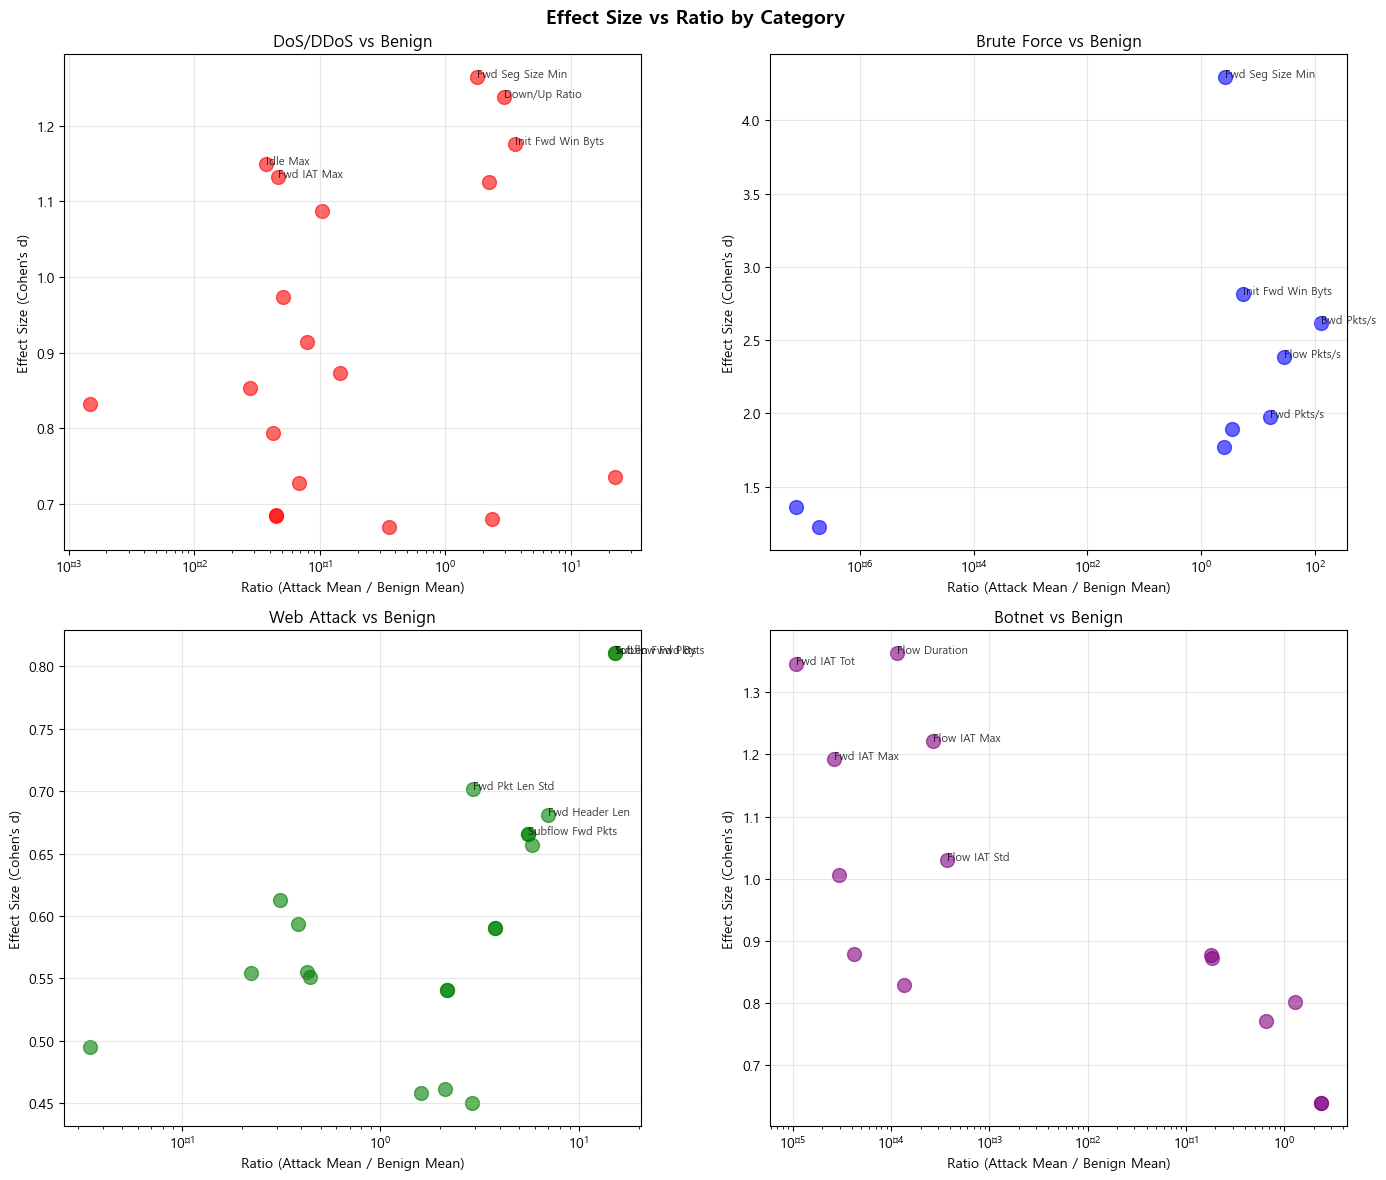

In [ ]:
# Visualization 1: Effect Size vs Ratio Scatter Plot (4 categories in one figure)
print("Visualization 1: Effect Size vs Ratio Scatter Plot")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()
colors = ['red', 'blue', 'green', 'purple']

for idx, category in enumerate(attack_categories):
    ax = axes[idx]
    data = all_significant[category].head(20).copy()  # Top 20

    # To use log scale, ratio must be greater than 0
    # Filter out invalid values (important!!)
    data = data[(data['ratio'] > 0) & np.isfinite(data['ratio']) & np.isfinite(data['cohens_d'])]

    # Terminal output
    print("\n" + "="*70)
    print(f"[{category}] Effect Size vs Ratio (Top Features)")
    print("="*70)
    print(f"{'Rank':>4} {'Feature':30s} {'Ratio (x)':>15s} {'Cohen d (y)':>15s}")
    print("-"*70)

    for i, (_, row) in enumerate(data.iterrows(), 1):
        print(f"{i:4d} {row['feature']:30s} {row['ratio']:15.6f} {row['cohens_d']:15.6f}")

    # Scatter plot
    ax.scatter(
        data['ratio'],
        data['cohens_d'],
        c=colors[idx],
        alpha=0.6,
        s=100
    )

    # Top 5 labels
    for _, row in data.head(5).iterrows():
        ax.annotate(
            row['feature'],
            (row['ratio'], row['cohens_d']),
            fontsize=8,
            alpha=0.8
        )

    ax.set_xlabel('Ratio (Attack Mean / Benign Mean)')
    ax.set_ylabel("Effect Size (Cohen's d)")
    ax.set_title(f'{category} vs Benign')
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log')  # Safe because only ratio > 0 values remain

plt.suptitle('Effect Size vs Ratio by Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Dos/DDos
```text
1. 시간 관련 feature의 ratio값이 매우 낮음 => Idle Max, Fwd IAT Max < 0.1
-> 쉬지 않고 연속으로 패킷 전송(폭주)
2. Down/Up ratio가 매우 높음
-> 서버에서 응답을 많이 받으려 함(서비스 마비 목적)
3. PSH Flag Cnt가 매우 높음
-> 데이터를 즉시 전달하라는 플래그 많음
4. Init Fwd Win Byts 높음
-> TCP 연결 시작 시 Forward 방향의 초기 윈도우 크기가 매우 큼
5. 시간 관련(상관관계 높음): Idle Max, Fwd IAT Max, Flow IAT Max
-> Idle Max 사용(d값이 제일 높음)

   IF Idle Max < threshold_low 
      AND Down/Up Ratio > threshold_high
      AND Init Fwd Win Byts > threshold_high
      THEN "DoS/DDoS"
```

### Brute Force
```text
=> 고려해야될 거 많아서 뒤에 더 분석.
```

### Web attack
```text
1. Subflow Fwd Byts(Forward 방향으로 전송된 총 바이트 수)가 매우 큼 
-> 비정상의 경우, 수백~수천 바이트
2. Fwd Header Len(Forward 방향 패킷의 헤더 길이 합계)가 큼
-> http 헤더에 악성코드 삽입
3. Fwd Pkt Len Std(Forward 방향 패킷 길이의 표준편차)
-> web attack의 경우, 다양한 공격을 시도해 패킷의 크기가 다양함. 

한계
   탐지 성능:   
      - Effect Size: 0.5 ~ 0.81 (Medium)
      - 예상 정확도: 다른 카테고리 대비 낮음
      - 오탐(False Positive) 가능성 높음
   원인
      - Flow 레벨 데이터 한계: Payload 내용 분석 불가
      - 정상 HTTP와 패턴 유사: SQL Injection, XSS도 HTTP 요청 형태
      - 샘플 수 부족: 743개 (다른 카테고리 대비 적음)
   권장 사항
      - Web Attack은 "의심" 수준으로 탐지
      - 정밀 탐지를 위해 WAF(Web Application Firewall) 병행 권장
      - Deep Packet Inspection으로 Payload 분석 필요

   IF Subflow Fwd Byts > threshold
      AND Fwd Header Len > threshold
      AND Fwd Pkt Len Std > threshold
      THEN "Web Attack 의심"

```

### Botnet
```text
1. 시간 관련 feature가 극도로 낮음 => Flow Duration(8,700배), Fwd IAT Tot(90,000배)
-> 매우 짧은 연결
2. 패킷 크기가 작음 -> Pkt Len Mean
3. IAT(Inter-Arrival Time) 관련이 모두 낮음
-> 패킷 간격이 일정하고 짧음
4. DDos와의 차이점: 
   DDos     - Idle Max가 낮음               -> 폭주
   Botnet   - flow duration이 극도로 낮음    -> 짧은 연결
5. 시간 관련(상관관계 높음): Flow Duration, Fwd IAT Tot, Flow IAT Max, Fwd IAT Max, Flow IAT Std, Fwd IAT Std
-> Flow Duration(d=1.36 가장 높음), Fwd IAT Tot(d=1.34, IAT 중 가장 높)

   IF Flow Duration < threshold_very_low
      AND Fwd IAT Tot < threshold_very_low
      AND Pkt Len Mean < threshold_low
      THEN "Botnet"


```

### Cohen's d 값이 매우 클 때 검증 - Brute Force: Fwd Seg Size Min
값이 너무 클 경우, 신뢰도가 떨어질 수 있음

In [ ]:

benign = df[df['Category'] == 'Benign']
brute_force = df[df['Category'] == 'Brute Force']

# ============================================================================
# 검증 1: 실제 분포 통계 확인

feature = 'Fwd Seg Size Min'

print("="*70)
print(f"[{feature}] 상세 분석")
print("="*70)

benign_vals = benign[feature].dropna()
attack_vals = brute_force[feature].dropna()

print(f"\nBenign (n={len(benign_vals)}):")
print(f"  Mean: {benign_vals.mean():.2f}")
print(f"  Median: {benign_vals.median():.2f}")
print(f"  Std: {benign_vals.std():.2f}")
print(f"  Min: {benign_vals.min():.2f}")
print(f"  Max: {benign_vals.max():.2f}")
print(f"  Skewness: {benign_vals.skew():.2f}")

print(f"\nBrute Force (n={len(attack_vals)}):")
print(f"  Mean: {attack_vals.mean():.2f}")
print(f"  Median: {attack_vals.median():.2f}")
print(f"  Std: {attack_vals.std():.2f}")
print(f"  Min: {attack_vals.min():.2f}")
print(f"  Max: {attack_vals.max():.2f}")
print(f"  Skewness: {attack_vals.skew():.2f}")

# ============================================================================
# 검증 2: Cliff's Delta (비모수 Effect Size)

def cliffs_delta(x, y):
    """
    Cliff's Delta 계산 (비모수 effect size)
    """
    n_x, n_y = len(x), len(y)
    
    # 모든 쌍 비교
    greater = 0
    less = 0
    
    for xi in x:
        for yi in y:
            if xi > yi:
                greater += 1
            elif xi < yi:
                less += 1
    
    delta = (greater - less) / (n_x * n_y)
    return delta

# 샘플이 크면 샘플링해서 계산 (시간 절약)
sample_size = min(1000, len(benign_vals), len(attack_vals))
benign_sample = benign_vals.sample(n=sample_size, random_state=42)
attack_sample = attack_vals.sample(n=sample_size, random_state=42)

cliff_d = cliffs_delta(attack_sample.values, benign_sample.values)

print(f"\n=== Effect Size 비교 ===")
print(f"Cohen's d: 4.30")
print(f"Cliff's Delta: {cliff_d:.3f}")

if abs(cliff_d) > 0.474:
    print("  → Cliff's Delta도 Large! 신뢰 가능")
elif abs(cliff_d) > 0.33:
    print("  → Cliff's Delta는 Medium. Cohen's d가 과장됐을 수 있음")
else:
    print("  → Cliff's Delta는 Small. Cohen's d가 과장됨!")

# ============================================================================
# 검증 3: 분포 겹침 정도 확인
# Benign의 max와 Attack의 min 비교

benign_max = benign_vals.quantile(0.95)  # 상위 5% 제외
attack_min = attack_vals.quantile(0.05)  # 하위 5% 제외

print(f"\n=== 분포 겹침 확인 ===")
print(f"Benign 95%: {benign_max:.2f}")
print(f"Attack 5%: {attack_min:.2f}")

if attack_min > benign_max:
    print("  → 두 분포가 거의 안 겹침! 신뢰 가능")
else:
    overlap_pct = (benign_vals > attack_min).mean() * 100
    print(f"  → 겹치는 비율: {overlap_pct:.1f}%")
    if overlap_pct < 10:
        print("  → 겹침 적음. 신뢰 가능")
    else:
        print("  → 겹침 많음. 주의 필요")

# ============================================================================
# 검증 4: Bootstrap 신뢰구간

def bootstrap_cohens_d(x, y, n_bootstrap=1000):
    """
    Bootstrap으로 Cohen's d 신뢰구간 계산
    """
    d_values = []
    
    for _ in range(n_bootstrap):
        # 복원 추출
        x_sample = np.random.choice(x, size=len(x), replace=True)
        y_sample = np.random.choice(y, size=len(y), replace=True)
        
        # Cohen's d 계산
        pooled_std = np.sqrt((x_sample.std()**2 + y_sample.std()**2) / 2)
        if pooled_std > 0:
            d = abs(x_sample.mean() - y_sample.mean()) / pooled_std
            d_values.append(d)
    
    return np.percentile(d_values, [2.5, 97.5])

ci_low, ci_high = bootstrap_cohens_d(benign_sample.values, attack_sample.values)

print(f"\n=== Cohen's d 신뢰구간 (95%) ===")
print(f"Cohen's d: 4.30")
print(f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]")

ci_width = ci_high - ci_low
if ci_width < 1.0:
    print("  → 신뢰구간 좁음. 안정적!")
else:
    print("  → 신뢰구간 넓음. 불안정할 수 있음")

[Fwd Seg Size Min] 상세 분석

Benign (n=11307):
  Mean: 15.41
  Median: 20.00
  Std: 8.09
  Min: 0.00
  Max: 48.00
  Skewness: -0.08

Brute Force (n=2324):
  Mean: 40.00
  Median: 40.00
  Std: 0.00
  Min: 40.00
  Max: 40.00
  Skewness: 0.00

=== Effect Size 비교 ===
Cohen's d: 4.30
Cliff's Delta: 0.996
  → Cliff's Delta도 Large! 신뢰 가능 ✅

=== 분포 겹침 확인 ===
Benign 95%: 32.00
Attack 5%: 40.00
  → 두 분포가 거의 안 겹침! 신뢰 가능 ✅

=== Cohen's d 신뢰구간 (95%) ===
Cohen's d: 4.30
95% CI: [4.22, 4.62]
  → 신뢰구간 좁음. 안정적! ✅


Brute Force의 Fwd Seg Size Min이 모든 샘플에서 정확히 40<br>
표준편차 = 0 (변동 없음)<br>
Skewness = 0 (완벽히 대칭, 사실 값이 하나뿐이라 당연)

Cliff's Delta = 0.996<br>
= Brute Force 값이 Benign 값보다 큰 경우가 99.6%<br>
= 거의 모든 비교에서 Brute Force > Benign<br>

Benign 95%: 32.00  (Benign의 95%가 32 이하)<br>
Attack 5%: 40.00   (Attack의 5%도 40 이상)<br>
=> 안겹침

매우 간단하고 강력한 Rule<br>
IF Fwd Seg Size Min == 40 THEN "Brute Force 의심"

더 관대하게<br>
IF Fwd Seg Size Min > 35 THEN "Brute Force 의심"


### Brute Force 주요 feature 상관관계 확인
Bwd Pkts/s, Flow Pkts/s, Fwd Pkts/s가 중복인지 확인하기<br>
brute의 경우, d값이 큰 경우가 많아, 모두 반영하면 과적합의 위험이 있음 + 하나라도 안 맞으면 탐지 실패 <br>
-> 상관관계 고려 후 중복 제거

Part 1: Brute Force 주요 Feature 상관관계


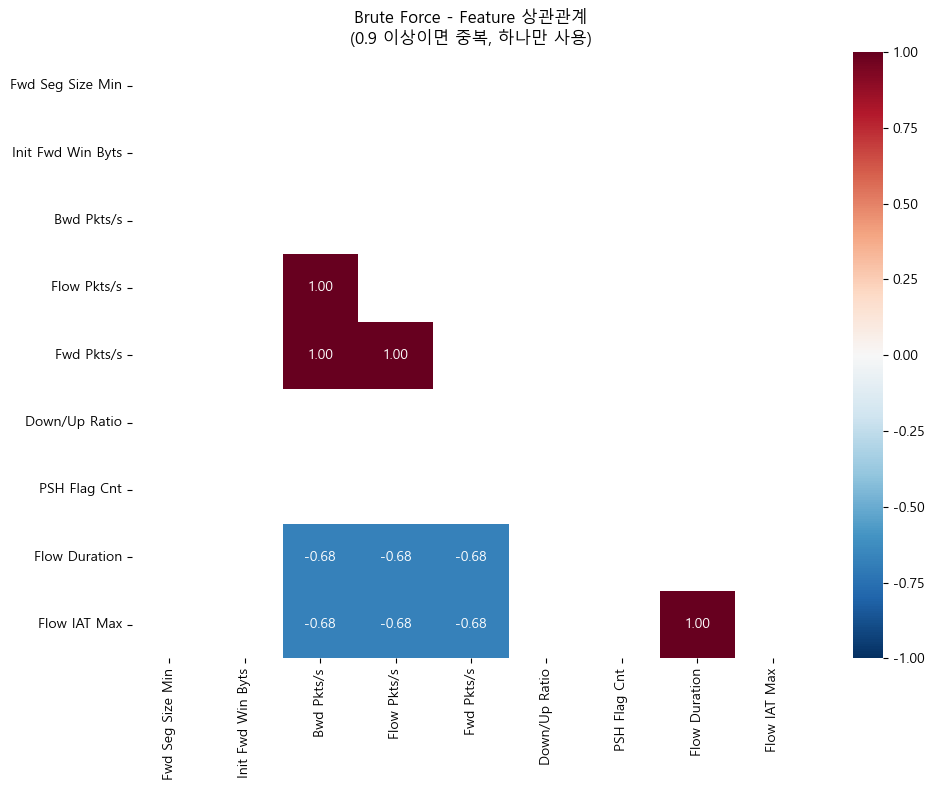


높은 상관관계 (|r| > 0.8):
  Bwd Pkts/s ↔ Flow Pkts/s: 1.000
  Bwd Pkts/s ↔ Fwd Pkts/s: 1.000
  Flow Pkts/s ↔ Fwd Pkts/s: 1.000
  Flow Duration ↔ Flow IAT Max: 1.000


In [13]:
# Brute Force 주요 Feature 상관관계 확인
print("="*70)
print("Part 1: Brute Force 주요 Feature 상관관계")
print("="*70)

brute_force = df[df['Category'] == 'Brute Force']

# 분석할 Feature들
bf_features = [
    'Fwd Seg Size Min', 'Init Fwd Win Byts', 'Bwd Pkts/s', 
    'Flow Pkts/s', 'Fwd Pkts/s', 'Down/Up Ratio', 
    'PSH Flag Cnt', 'Flow Duration', 'Flow IAT Max'
]

# 존재하는 Feature만 선택
bf_features = [f for f in bf_features if f in df.columns]

# 상관관계 계산
corr_matrix = brute_force[bf_features].corr()

# 시각화
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Brute Force - Feature 상관관계\n(0.9 이상이면 중복, 하나만 사용)')
plt.tight_layout()
plt.show()

# 높은 상관관계 출력
print("\n높은 상관관계 (|r| > 0.8):")
for i in range(len(bf_features)):
    for j in range(i+1, len(bf_features)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.8:
            print(f"  {bf_features[i]} ↔ {bf_features[j]}: {corr_val:.3f}")


```text
전송률 관련 피처: 셋 다 1.0으로 동일한 정보(Bwd Pkts, Flow Pkts, Fwd Pkts)
=> Bwd Pkts

시간 관련 피처: 둘 다 1.0으로 동일한 정보(Flow Duration, Flow IAT Max)
=> Flow Duration


   IF Fwd Seg Size Min > threshold
      AND Bwd Pkts/s > threshold
      AND Flow Duration < threshold
      AND Init Fwd Win Byts > threshold
      AND Down/Up Ratio > threshold
      AND PSH Flag Cnt > threshold
   THEN "Brute Force"

```

# 여기까지가 발표할 내용----(카테고리 별 피처 분석)

시각화 2: Benign Percentile Plot
분석할 Top 10 Feature: ['Idle Max', 'Flow IAT Max', 'Idle Mean', 'Fwd Seg Size Min', 'Down/Up Ratio', 'Init Fwd Win Byts', 'Fwd IAT Max', 'PSH Flag Cnt', 'Fwd IAT Std', 'Flow IAT Std']


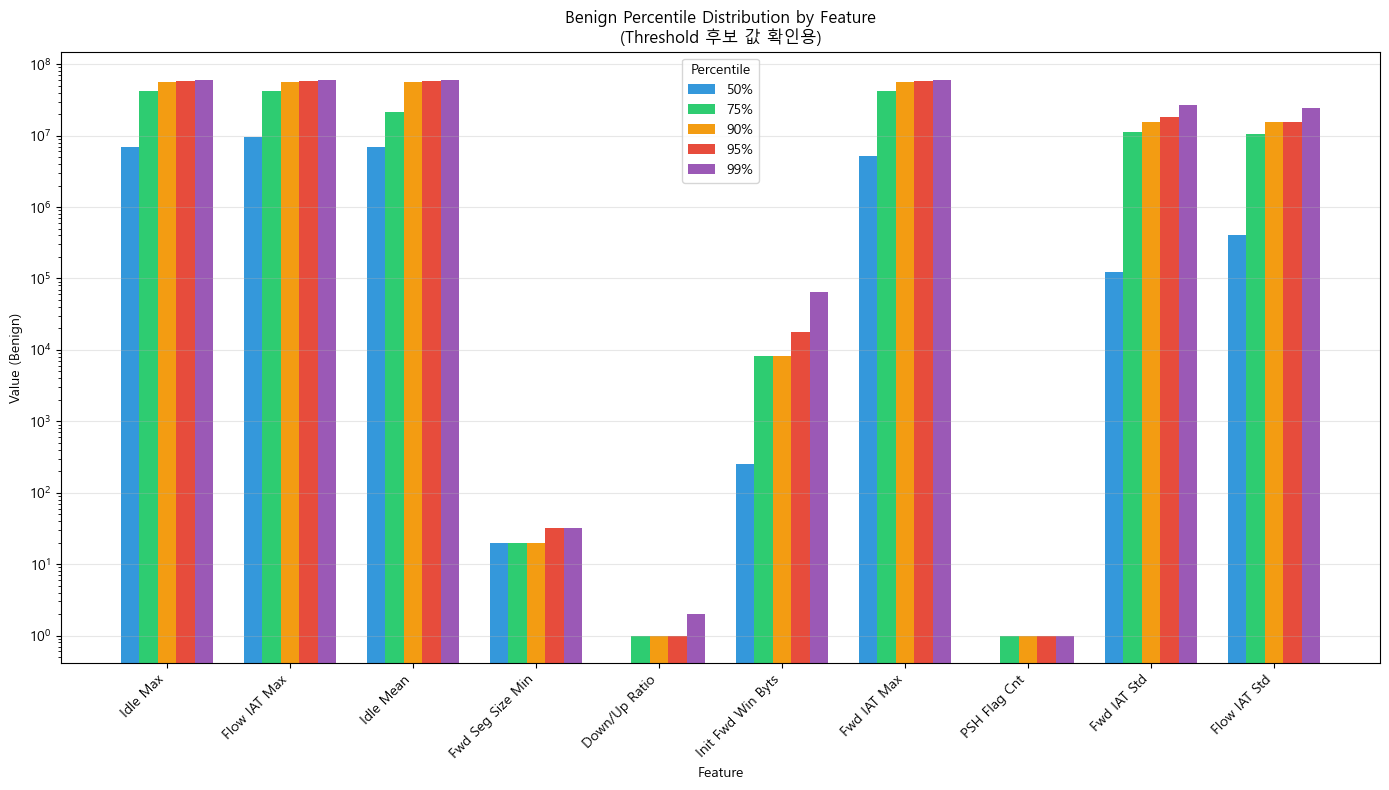

In [5]:
# 시각화 2: Benign Percentile Plot (Top 10 Feature)
print("시각화 2: Benign Percentile Plot")

# 모든 카테고리에서 공통적으로 중요한 Top 10 Feature 선택
all_top_features = []
for category in attack_categories:
    top_feats = all_significant[category].head(10)['feature'].tolist()
    all_top_features.extend(top_feats)

# 가장 많이 등장한 Feature 선택
from collections import Counter
feature_counts = Counter(all_top_features)
top_10_features = [feat for feat, count in feature_counts.most_common(10)]

print(f"분석할 Top 10 Feature: {top_10_features}")

# Percentile 계산
percentiles = [50, 75, 90, 95, 99]
percentile_data = []

for feat in top_10_features:
    feat_data = benign[feat].dropna()
    for p in percentiles:
        percentile_data.append({
            'feature': feat,
            'percentile': p,
            'value': np.percentile(feat_data, p)
        })

percentile_df = pd.DataFrame(percentile_data)

# 시각화
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(top_10_features))
width = 0.15
colors_p = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6']

for i, p in enumerate(percentiles):
    values = percentile_df[percentile_df['percentile'] == p]['value'].values
    bars = ax.bar(x + i*width, values, width, label=f'{p}%', color=colors_p[i])

ax.set_xlabel('Feature')
ax.set_ylabel('Value (Benign)')
ax.set_title('Benign Percentile Distribution by Feature\n(Threshold 후보 값 확인용)')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(top_10_features, rotation=45, ha='right')
ax.legend(title='Percentile')
ax.set_yscale('log')  # 값 범위가 크면 log scale
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


시각화 3: Feature 상관관계 Heatmap (Benign 기준)


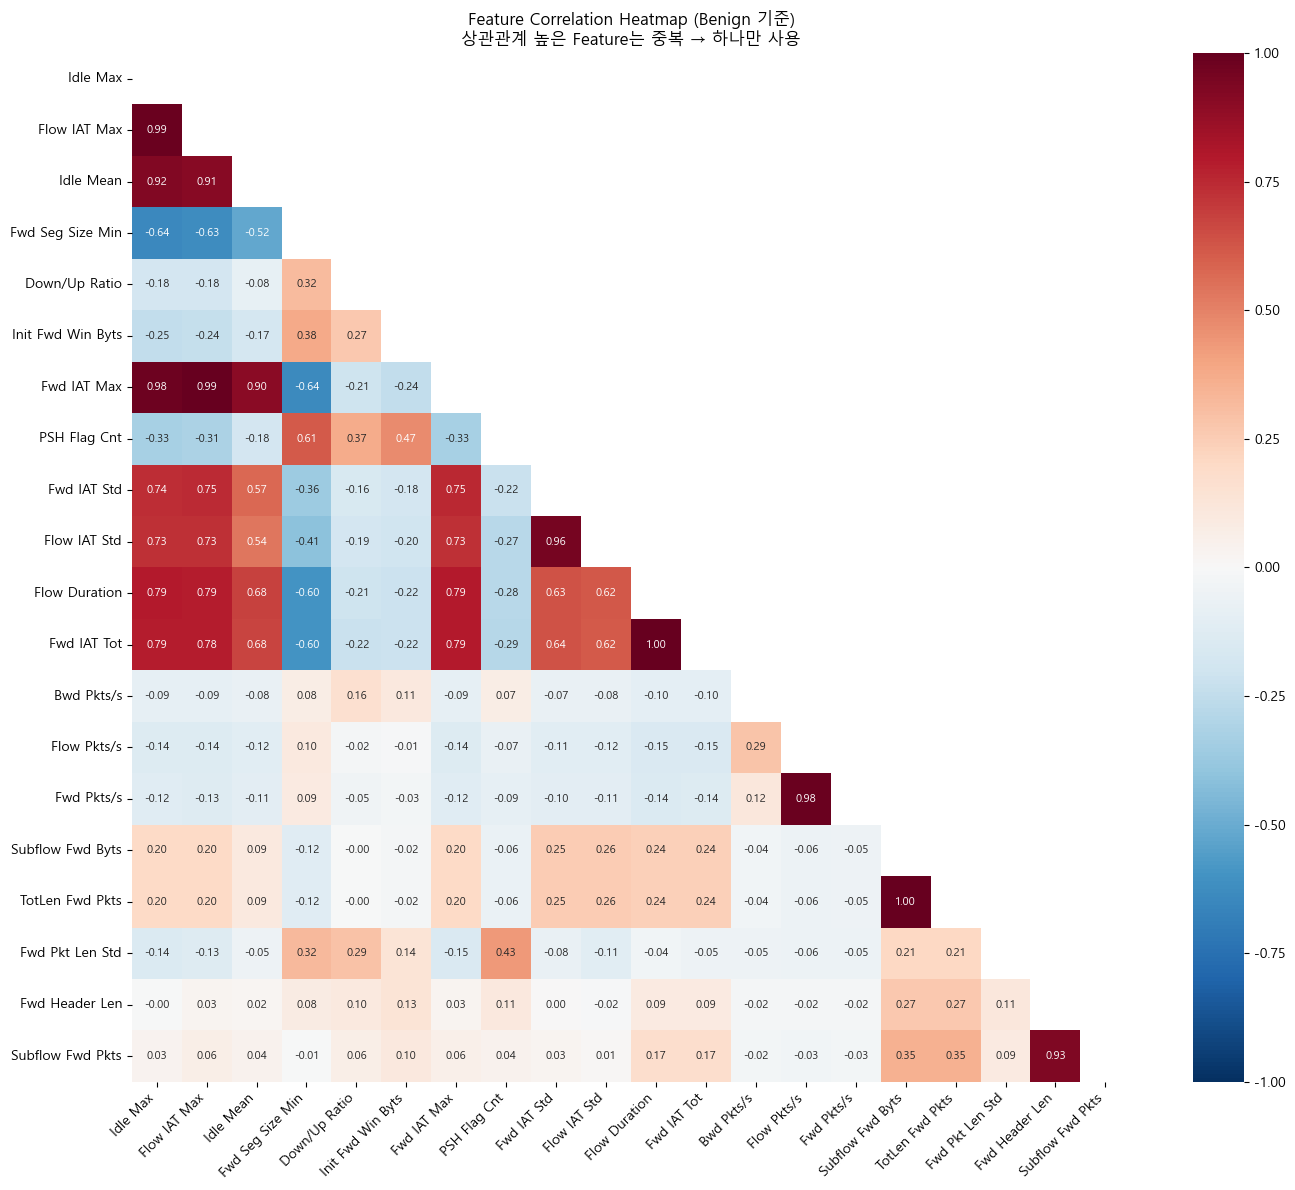

In [6]:
# 시각화 3: Feature 상관관계 Heatmap (Benign 기준, Top 20)
print("시각화 3: Feature 상관관계 Heatmap (Benign 기준)")

# Top 20 Feature 선택
top_20_features = [feat for feat, count in feature_counts.most_common(20)]

# Benign 데이터에서 상관관계 계산
corr_data = benign[top_20_features].corr()

fig, ax = plt.subplots(figsize=(14, 12))

mask = np.triu(np.ones_like(corr_data, dtype=bool))  # 상삼각 마스크
sns.heatmap(corr_data, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 8})

ax.set_title('Feature Correlation Heatmap (Benign 기준)\n상관관계 높은 Feature는 중복 → 하나만 사용', 
             fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



시각화 4: 카테고리별 Box Plot
Box Plot Feature: ['Idle Max', 'Flow IAT Max', 'Idle Mean', 'Fwd Seg Size Min', 'Down/Up Ratio']


C:\Users\3eunh\AppData\Local\Temp\ipykernel_15808\2938851891.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=labels, patch_artist=True)
C:\Users\3eunh\AppData\Local\Temp\ipykernel_15808\2938851891.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=labels, patch_artist=True)
C:\Users\3eunh\AppData\Local\Temp\ipykernel_15808\2938851891.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=labels, patch_artist=True)
C:\Users\3eunh\AppData\Local\Temp\ipykernel_15808\2938851891.py:29: MatplotlibDeprecationWarning: Th

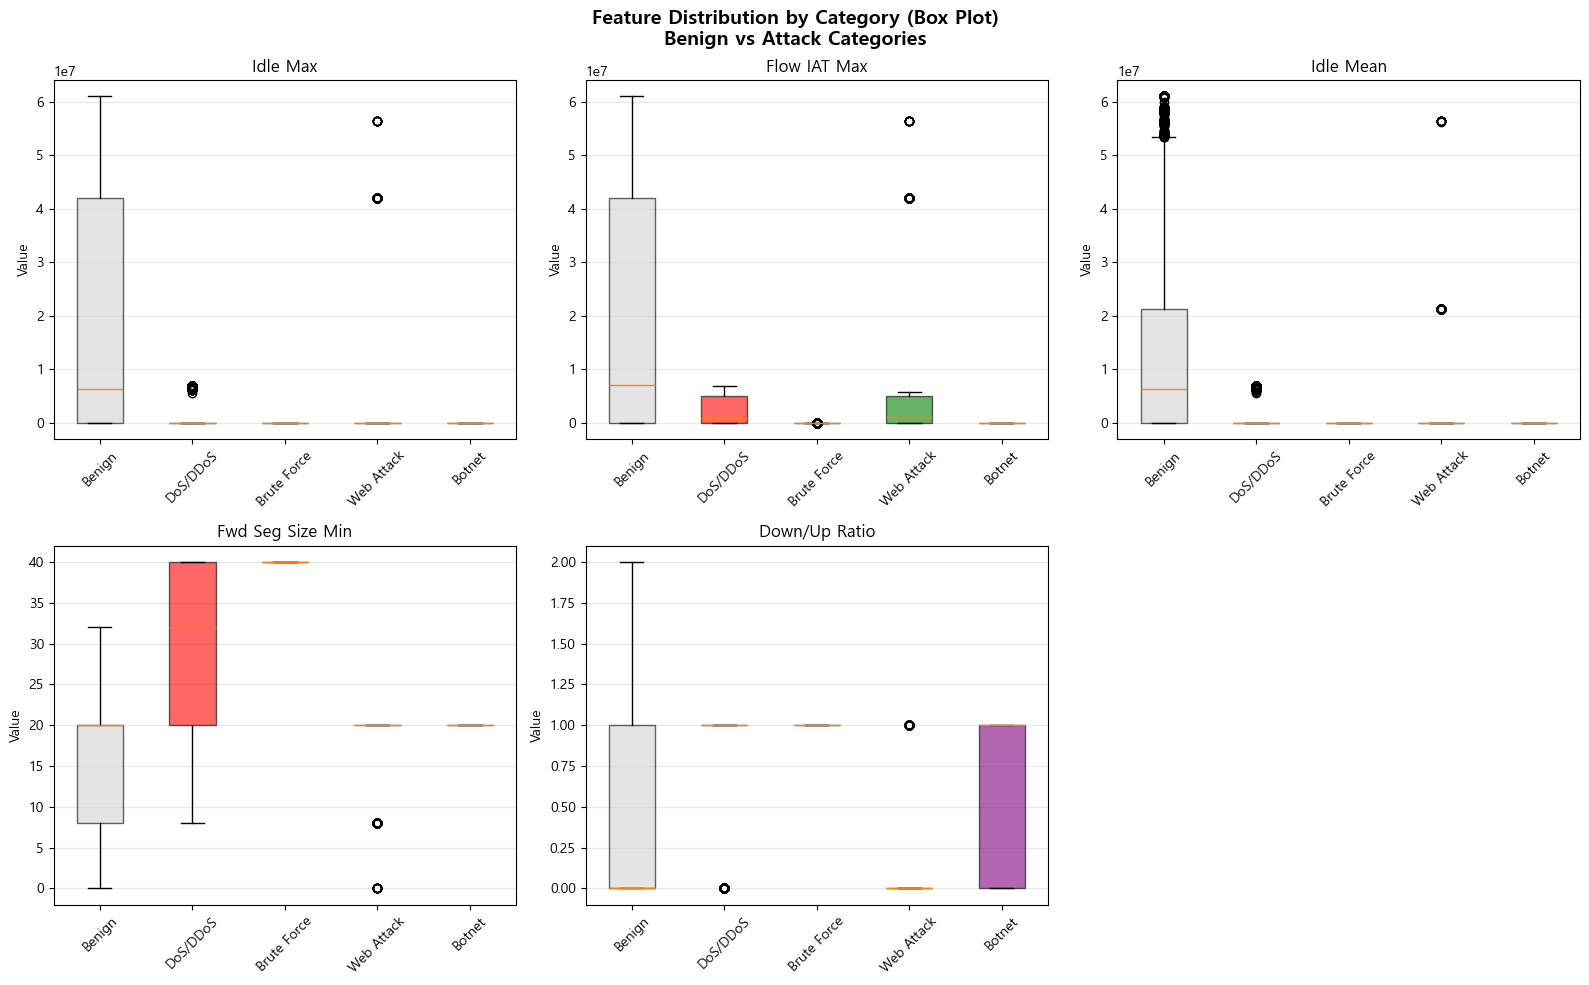

In [7]:
# 시각화 4: 카테고리별 Box Plot (Top 5 Feature)

print("\n" + "="*70)
print("시각화 4: 카테고리별 Box Plot")
print("="*70)

top_5_features = [feat for feat, count in feature_counts.most_common(5)]
print(f"Box Plot Feature: {top_5_features}")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

categories_with_benign = ['Benign'] + attack_categories

for idx, feat in enumerate(top_5_features):
    ax = axes[idx]
    
    # 각 카테고리별 데이터
    plot_data = []
    labels = []
    for cat in categories_with_benign:
        cat_data = df[df['Category'] == cat][feat].dropna()
        # Outlier 제거 (99 percentile 이하만)
        upper = cat_data.quantile(0.99)
        cat_data = cat_data[cat_data <= upper]
        plot_data.append(cat_data)
        labels.append(cat)
    
    bp = ax.boxplot(plot_data, labels=labels, patch_artist=True)
    
    # 색상 지정
    box_colors = ['lightgray', 'red', 'blue', 'green', 'purple']
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    ax.set_title(feat)
    ax.set_ylabel('Value')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')

# 빈 subplot 제거
for idx in range(len(top_5_features), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Feature Distribution by Category (Box Plot)\nBenign vs Attack Categories', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



시각화 5: 카테고리별 Top Feature Bar Chart


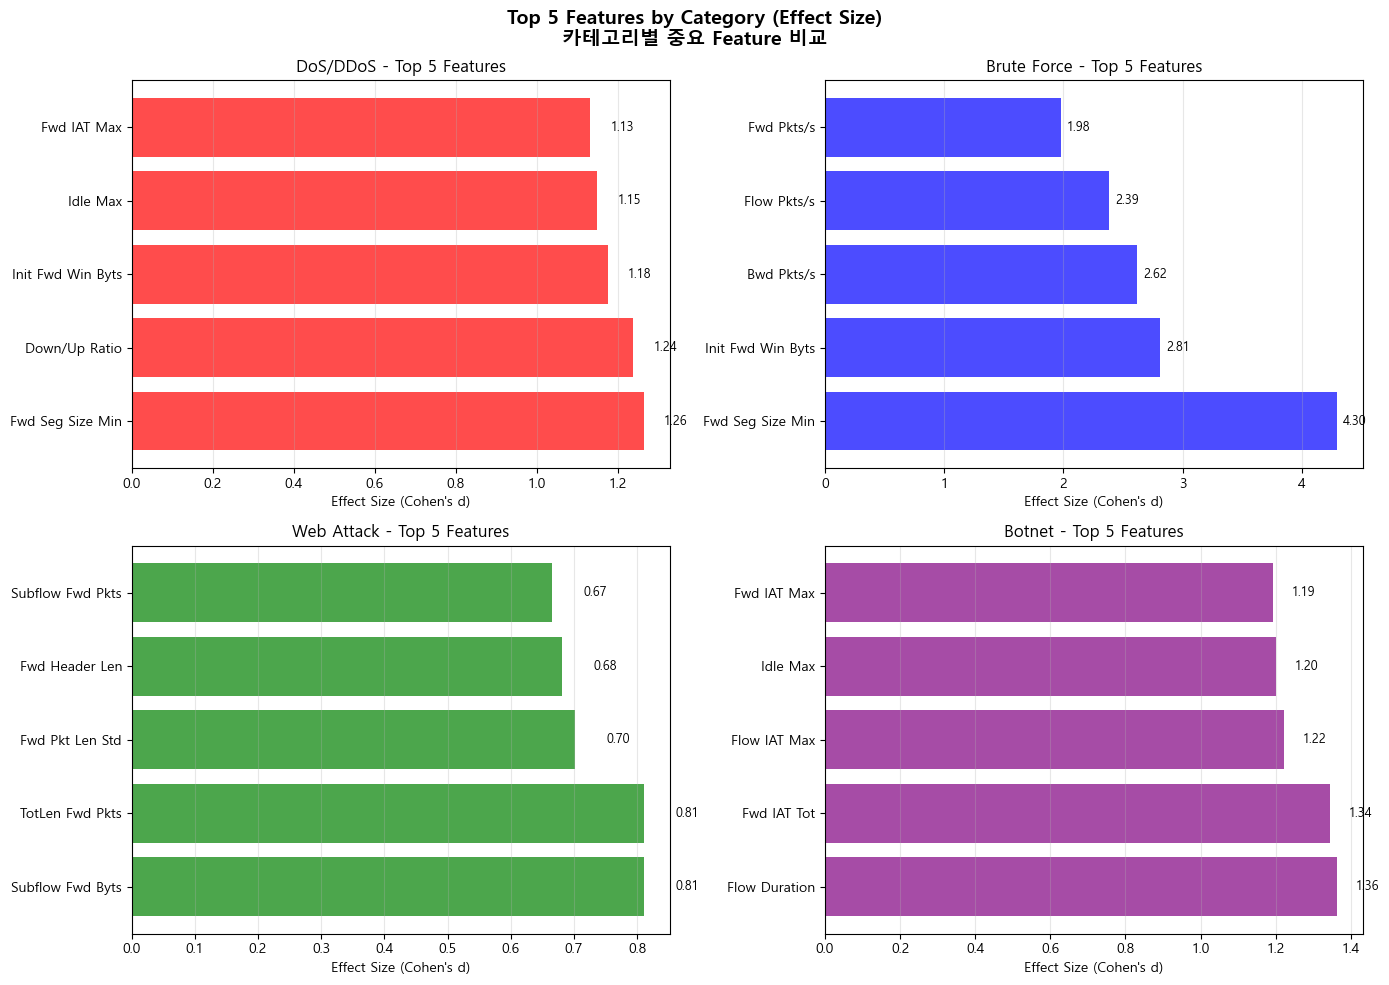

In [8]:
# 시각화 5: 카테고리별 Top 5 Feature Bar Chart (Effect Size)
print("시각화 5: 카테고리별 Top Feature Bar Chart")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
colors = ['red', 'blue', 'green', 'purple']

for idx, category in enumerate(attack_categories):
    ax = axes[idx]
    top5 = all_significant[category].head(5)
    
    bars = ax.barh(range(len(top5)), top5['cohens_d'].values, color=colors[idx], alpha=0.7)
    ax.set_yticks(range(len(top5)))
    ax.set_yticklabels(top5['feature'].values)
    ax.set_xlabel('Effect Size (Cohen\'s d)')
    ax.set_title(f'{category} - Top 5 Features')
    ax.grid(True, alpha=0.3, axis='x')
    
    # 값 표시
    for i, (bar, val) in enumerate(zip(bars, top5['cohens_d'].values)):
        ax.text(val + 0.05, i, f'{val:.2f}', va='center', fontsize=9)

plt.suptitle('Top 5 Features by Category (Effect Size)\n카테고리별 중요 Feature 비교', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



In [9]:
# 분석 요약
print("\n" + "="*70)
print("분석 요약")
print("="*70)

print("\n[카테고리별 Top 5 Feature]")
for category in attack_categories:
    print(f"\n{category}:")
    top5 = all_significant[category].head(5)
    for i, (_, row) in enumerate(top5.iterrows(), 1):
        print(f"  {i}. {row['feature']} (Effect Size: {row['cohens_d']:.2f}, Ratio: {row['ratio']:.1f}x)")

print("\n[공통 Top Feature]")
print("모든 카테고리에서 자주 등장하는 Feature:")
for feat, count in feature_counts.most_common(10):
    print(f"  - {feat}: {count}개 카테고리에서 Top 10")

print("\n" + "="*70)
print("시각화 완료!")
print("="*70)


분석 요약

[카테고리별 Top 5 Feature]

DoS/DDoS:
  1. Fwd Seg Size Min (Effect Size: 1.26, Ratio: 1.8x)
  2. Down/Up Ratio (Effect Size: 1.24, Ratio: 2.9x)
  3. Init Fwd Win Byts (Effect Size: 1.18, Ratio: 3.6x)
  4. Idle Max (Effect Size: 1.15, Ratio: 0.0x)
  5. Fwd IAT Max (Effect Size: 1.13, Ratio: 0.0x)

Brute Force:
  1. Fwd Seg Size Min (Effect Size: 4.30, Ratio: 2.6x)
  2. Init Fwd Win Byts (Effect Size: 2.81, Ratio: 5.4x)
  3. Bwd Pkts/s (Effect Size: 2.62, Ratio: 128.9x)
  4. Flow Pkts/s (Effect Size: 2.39, Ratio: 29.2x)
  5. Fwd Pkts/s (Effect Size: 1.98, Ratio: 16.5x)

Web Attack:
  1. Subflow Fwd Byts (Effect Size: 0.81, Ratio: 15.3x)
  2. TotLen Fwd Pkts (Effect Size: 0.81, Ratio: 15.3x)
  3. Fwd Pkt Len Std (Effect Size: 0.70, Ratio: 2.9x)
  4. Fwd Header Len (Effect Size: 0.68, Ratio: 7.0x)
  5. Subflow Fwd Pkts (Effect Size: 0.67, Ratio: 5.6x)

Botnet:
  1. Flow Duration (Effect Size: 1.36, Ratio: 0.0x)
  2. Fwd IAT Tot (Effect Size: 1.34, Ratio: 0.0x)
  3. Flow IAT Max (Effect